# Inicio rápido: datos municipales y mapa interactivo

Este notebook busca una variable, descarga datos desde SINIM y construye un mapa comunal interactivo con [Kepler.gl](https://kepler.gl/). El ejemplo utiliza los ingresos por patentes municipales (`4173`) para el último año disponible.

## 1. Instalación

`keplergl` se instala solo para este ejemplo visual; no es necesario para el uso habitual de `mcp-sinim`. Este notebook requiere **Python 3.10, 3.11 o 3.12**, porque las dependencias actuales de Kepler.gl todavía no son compatibles con Python 3.13. Reinicia el kernel si Jupyter lo solicita.

In [1]:
%pip install --quiet --upgrade mcp-sinim keplergl matplotlib "setuptools<81"

Note: you may need to restart the kernel to use updated packages.


## 2. Buscar y descargar datos SINIM

In [2]:
from mcp_sinim import SINIMClient

client = SINIMClient(corrmon=True)
client.search("patentes municipales", limit=5)[["code", "name", "unit", "score"]]

,code,name,unit,score
0,1310,Eficiencia Cobro Patentes Municipales,%,90.0
1,1311,Monto Patentes Municipales Pagadas,M$,90.0
2,4173,Ingresos por Patentes Municipales de Beneficio...,M$,90.0
3,739,Participación Masculina de Funcionarios Munici...,%,85.5
4,778,Porcentaje de Puntajes PAES Igual o Superior a...,%,85.5


In [3]:
codigo = "4173"
ultimo_anio = client.years()[-1]

datos = client.get(codigo, years=[ultimo_anio])
datos = datos.dropna(subset=["value"]).copy()
print(f"{len(datos)} municipios con datos para {ultimo_anio}")
datos.head()

340 municipios con datos para 2025


,cod_municipio,nombre_municipio,anio,code,name,value,unit
0,01101,IQUIQUE,2025,4173,Ingresos por Patentes Municipales de Beneficio...,14435454.0,M$
1,01107,ALTO HOSPICIO,2025,4173,Ingresos por Patentes Municipales de Beneficio...,1636937.0,M$
2,01401,POZO ALMONTE,2025,4173,Ingresos por Patentes Municipales de Beneficio...,2656810.0,M$
3,01402,CAMIÑA,2025,4173,Ingresos por Patentes Municipales de Beneficio...,3586.0,M$
4,01403,COLCHANE,2025,4173,Ingresos por Patentes Municipales de Beneficio...,703.0,M$


## 3. Unir los datos con polígonos comunales

Las geometrías provienen del repositorio [Chile-GeoJSON](https://github.com/fcortes/Chile-GeoJSON), elaborado a partir de mapas vectoriales de la Biblioteca del Congreso Nacional de Chile. La unión se realiza mediante el código CUT comunal.

In [4]:
import json
from urllib.request import urlopen

GEOJSON_URL = "https://raw.githubusercontent.com/fcortes/Chile-GeoJSON/master/comunas.geojson"

with urlopen(GEOJSON_URL) as respuesta:
    comunas = json.load(respuesta)

por_comuna = datos.assign(cod_municipio=datos["cod_municipio"].astype(str).str.zfill(5)).set_index(
    "cod_municipio"
)

features = []
for feature in comunas["features"]:
    codigo_cut = str(feature["properties"]["cod_comuna"]).zfill(5)
    if codigo_cut not in por_comuna.index:
        continue
    fila = por_comuna.loc[codigo_cut]
    feature["properties"].update(
        {
            "cod_municipio": codigo_cut,
            "municipio": fila["nombre_municipio"],
            "indicador": fila["name"],
            "valor": float(fila["value"]),
            "unidad": fila["unit"],
            "anio": int(fila["anio"]),
        }
    )
    features.append(feature)

mapa_geojson = {"type": "FeatureCollection", "features": features}
print(f"{len(features)} polígonos comunales listos para visualizar")

340 polígonos comunales listos para visualizar


## 4. Vista previa del mapa

Esta versión estática permite ver el resultado directamente en GitHub. Los colores representan el valor del indicador para cada comuna.

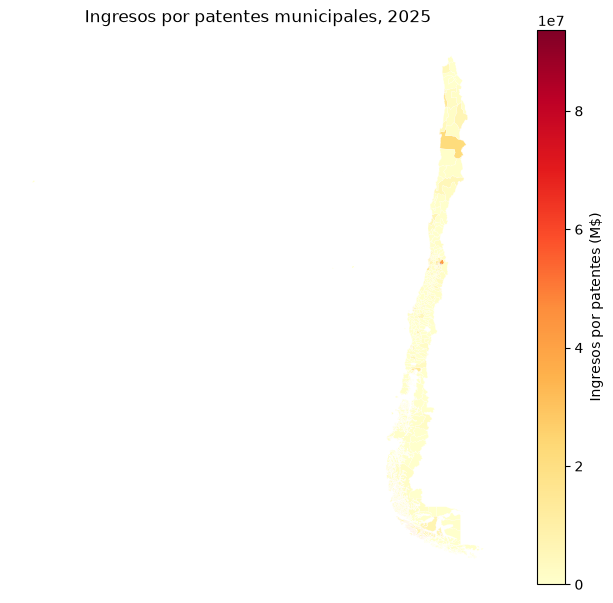

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

mapa_estatico = gpd.GeoDataFrame.from_features(mapa_geojson["features"], crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(8, 12))
mapa_estatico.plot(
    column="valor",
    cmap="YlOrRd",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Ingresos por patentes (M$)", "shrink": 0.6},
    ax=ax,
)
ax.set_title(f"Ingresos por patentes municipales, {ultimo_anio}")
ax.set_axis_off()
plt.show()

## 5. Mapa interactivo con Kepler.gl

Ejecuta esta celda localmente para abrir Kepler.gl. En su panel lateral puedes colorear por `valor`, filtrar por `Region` y consultar cada comuna. GitHub muestra la vista estática anterior porque no ejecuta widgets interactivos.

In [6]:
from keplergl import KeplerGl

mapa = KeplerGl(
    height=700,
    data={f"Ingresos por patentes {ultimo_anio}": mapa_geojson},
    show_docs=False,
)
mapa

## 6. Exportar el resultado (opcional)

El archivo HTML conserva la interacción y puede abrirse en cualquier navegador. No se incluye en el repositorio porque contiene todos los datos y geometrías del mapa.

In [7]:
mapa.save_to_html(
    file_name=f"mapa_patentes_sinim_{ultimo_anio}.html",
    read_only=True,
)
client.close()

Map saved to mapa_patentes_sinim_2025.html!
